<a href="https://www.kaggle.com/code/sonawanelalitsunil/used-car-price-prediction-ml-97-10?scriptVersionId=231664456" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/extensive-used-car-price-for-predictive-modeling/car_dataset.csv


### Title: Used Car Price Prediction Model

### Description: Developing a predictive model to estimate used car prices based on extensive historical data and key vehicle attributes.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/extensive-used-car-price-for-predictive-modeling/car_dataset.csv')

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.duplicated().sum()

2

In [9]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [10]:
df.shape

(301, 9)

In [11]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

## Data visualizations

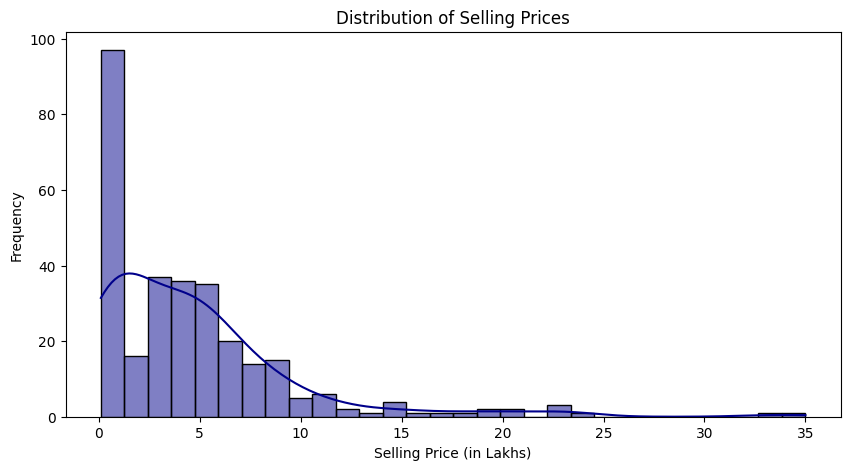

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Selling_Price'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

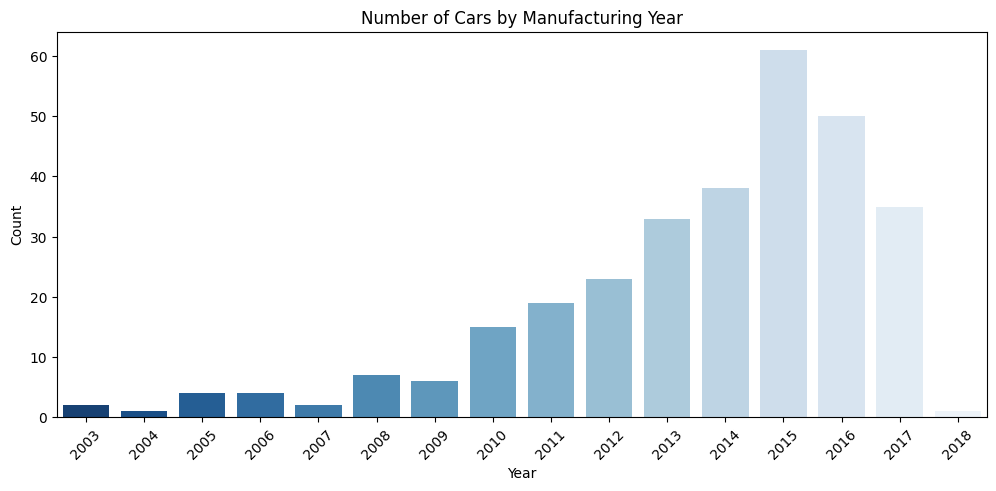

In [13]:
plt.figure(figsize=(12, 5))
sns.countplot(x=df['Year'], order=sorted(df['Year'].unique()), palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Number of Cars by Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


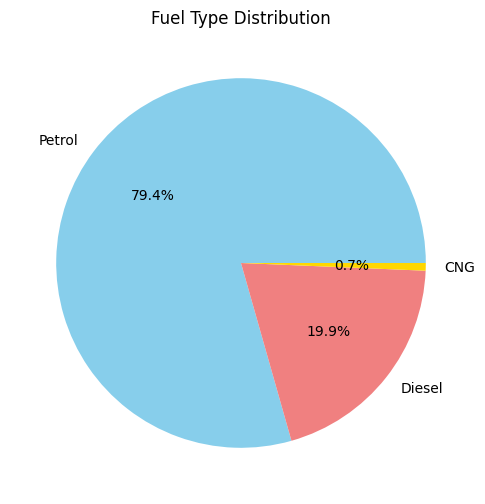

In [14]:
plt.figure(figsize=(6, 6))
df['Fuel_Type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral', 'gold'])
plt.title('Fuel Type Distribution')
plt.ylabel('')
plt.show()


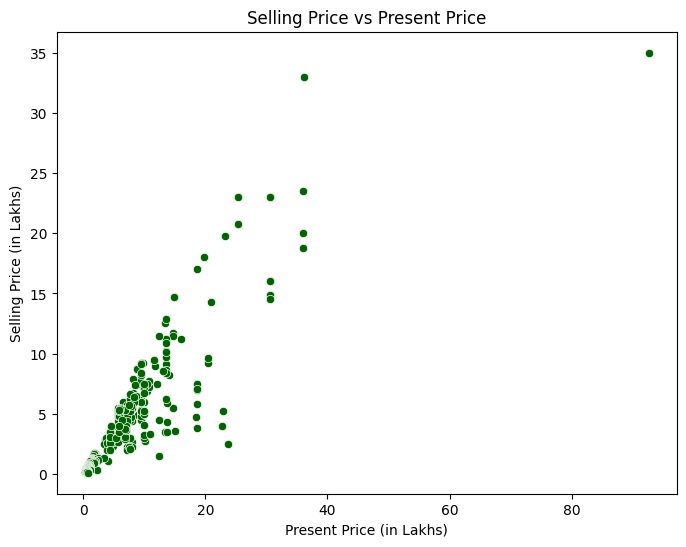

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Present_Price'], y=df['Selling_Price'], color='darkgreen')
plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


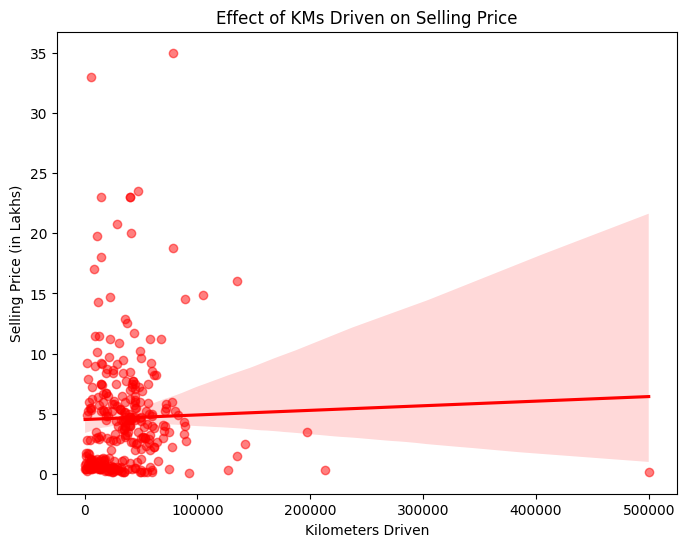

In [16]:
plt.figure(figsize=(8, 6))
sns.regplot(x=df['Kms_Driven'], y=df['Selling_Price'], scatter_kws={'alpha':0.5}, color='red')
plt.title('Effect of KMs Driven on Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


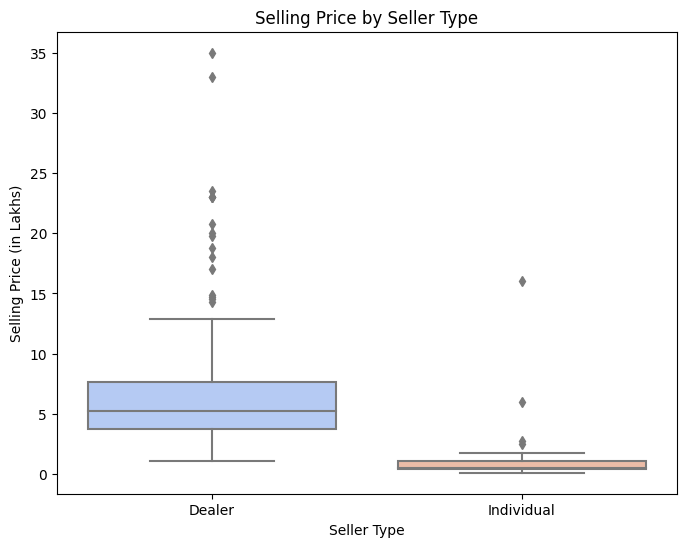

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Seller_Type'], y=df['Selling_Price'], palette='coolwarm')
plt.title('Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


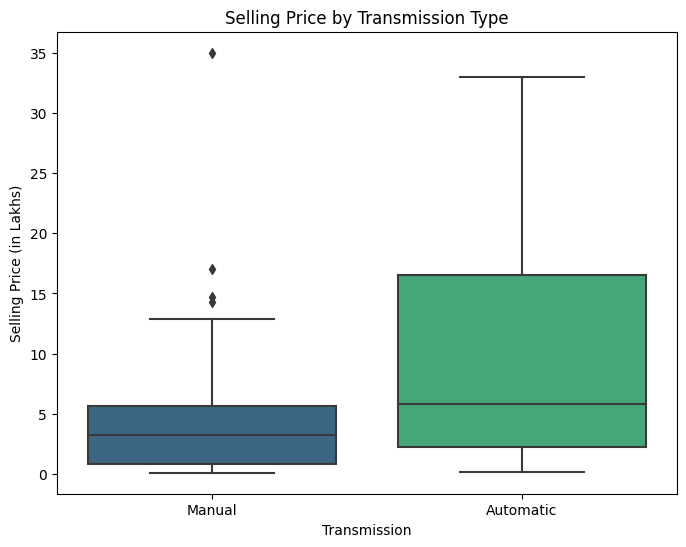

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Transmission'], y=df['Selling_Price'], palette='viridis')
plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


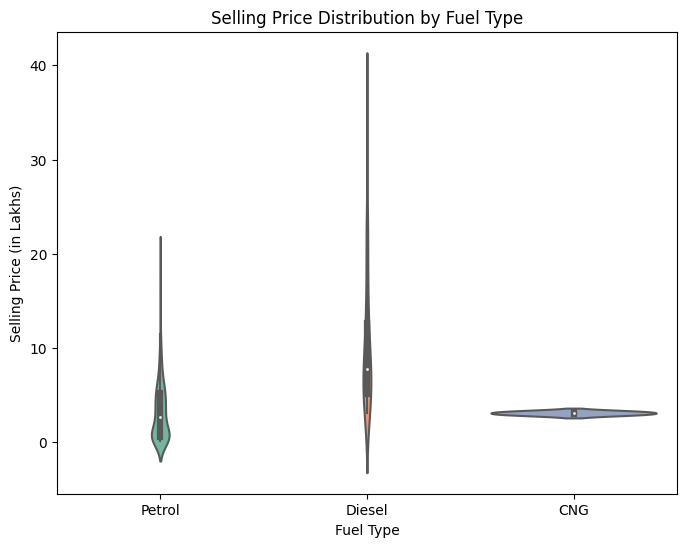

In [19]:
plt.figure(figsize=(8, 6))
sns.violinplot(x=df['Fuel_Type'], y=df['Selling_Price'], palette='Set2')
plt.title('Selling Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


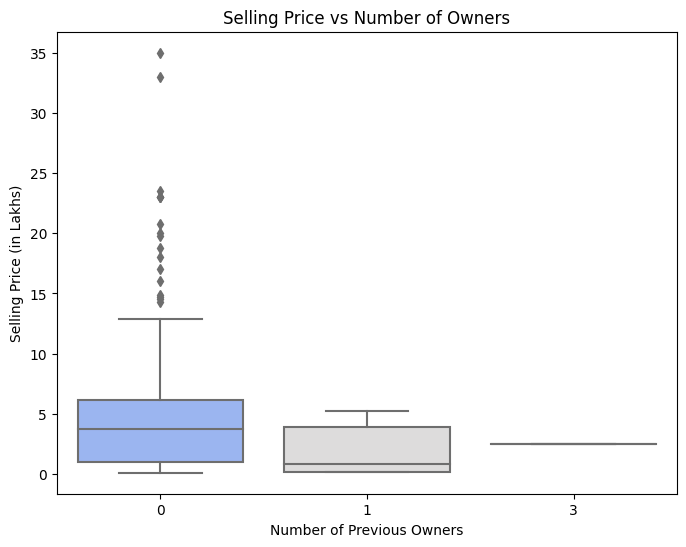

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Owner'].astype(str), y=df['Selling_Price'], palette='coolwarm')
plt.title('Selling Price vs Number of Owners')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


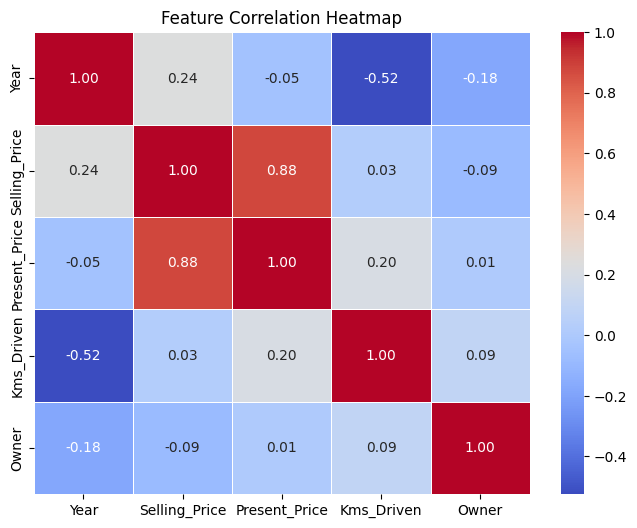

In [21]:
plt.figure(figsize=(8, 6))

# Selecting only numerical columns for correlation
num_df = df.select_dtypes(include=['number'])

sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


## predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [24]:
# Drop 'Car_Name' since it's non-numeric and not useful for price prediction
df.drop(columns=['Car_Name'], inplace=True)

In [25]:
# Apply Label Encoding for categorical columns
label_encoders = {}
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']


In [26]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [27]:
# Define target variable and features
X = df.drop(columns=['Selling_Price'])  # Features
y = df['Selling_Price']  # Target


In [28]:
# Split into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5)
}

In [30]:
# Train and evaluate each model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on test set
    
    r2 = r2_score(y_test, y_pred) * 100  # Convert to percentage
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append((name, r2, mae))
    

In [31]:
# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results, columns=["Model", "R² Score (%)", "Mean Absolute Error"])
print(results_df.sort_values(by="R² Score (%)", ascending=False))

                      Model  R² Score (%)  Mean Absolute Error
3         Gradient Boosting     97.104379             0.523835
2             Random Forest     96.169815             0.622349
1             Decision Tree     94.409768             0.755902
0         Linear Regression     84.680540             1.221762
5       K-Nearest Neighbors     -2.334429             3.419803
4  Support Vector Regressor     -9.528099             3.154554


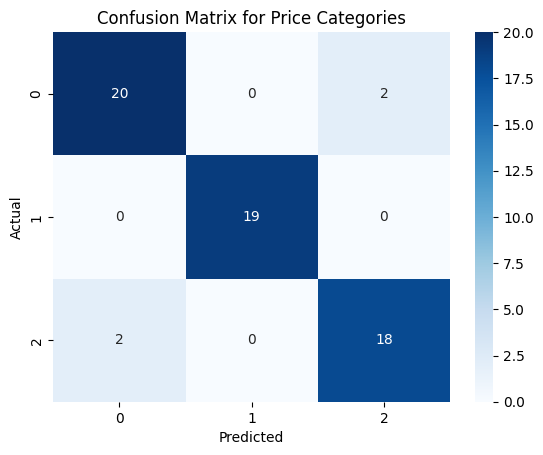

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       1.00      1.00      1.00        19
           2       0.90      0.90      0.90        20

    accuracy                           0.93        61
   macro avg       0.94      0.94      0.94        61
weighted avg       0.93      0.93      0.93        61



In [32]:
# Convert Selling Price into categories: Low, Medium, High
df['Price_Category'] = pd.qcut(df['Selling_Price'], q=3, labels=['Low', 'Medium', 'High'])

# Encode labels
df['Price_Category'] = LabelEncoder().fit_transform(df['Price_Category'])

# Train a classification model (e.g., Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

X = df.drop(columns=['Selling_Price', 'Price_Category'])  # Features
y = df['Price_Category']  # Target category

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Price Categories")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))


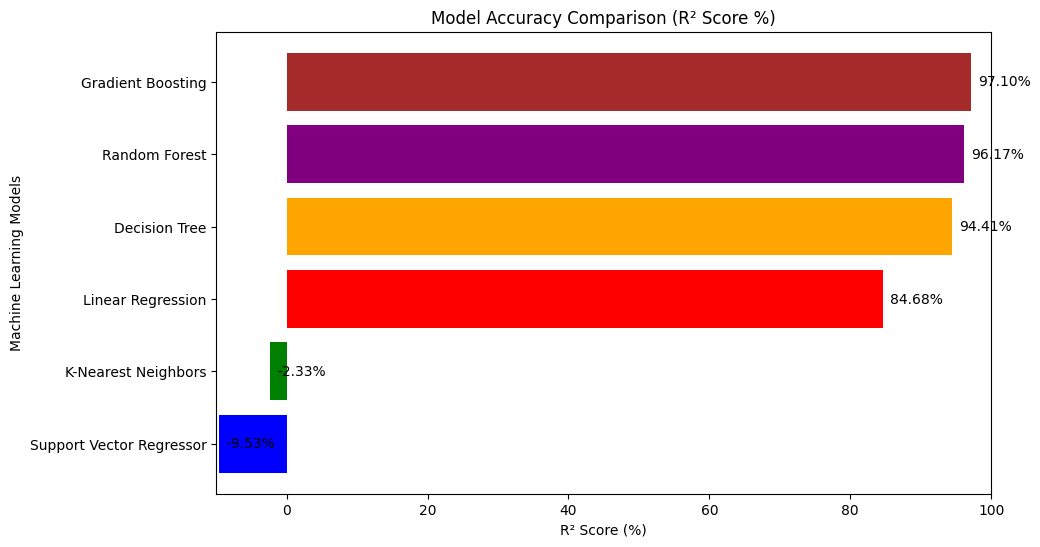

In [33]:
# Sort models by R² Score
results_df_sorted = results_df.sort_values(by="R² Score (%)", ascending=True)

# Plot bar graph
plt.figure(figsize=(10, 6))
plt.barh(results_df_sorted["Model"], results_df_sorted["R² Score (%)"], color=['blue', 'green', 'red', 'orange', 'purple', 'brown'])
plt.xlabel("R² Score (%)")
plt.ylabel("Machine Learning Models")
plt.title("Model Accuracy Comparison (R² Score %)")
plt.xlim(-10, 100)  # Adjust the range for better visibility

# Display values on bars
for index, value in enumerate(results_df_sorted["R² Score (%)"]):
    plt.text(value + 1, index, f"{value:.2f}%", va='center', fontsize=10)

plt.show()

## Thank you...pls upvote!!!!
